# MTH3302 : Méthodes probabilistes et statistiques pour l'I.A.

Jonathan Jalbert<br/>
Professeur agrégé au Département de mathématiques et de génie industriel<br/>
Polytechnique Montréal<br/>


# TD2 - Régression linéaire

Ce TD concerne la régression linéaire (Chapitre 2 du cours). À la fin de ce TD, vous devriez être avoir été en mesure de :
- Estimer les coefficients des paramètres de la régression linéaire simple avec la méthode des moindres carrés.
- Estimer les coefficients des paramètres de la régression linéaire multiple avec la méthode des moindres carrés.
- Calculer le coefficient de détermination.
- Sélectionner le meilleur modèle unidimensionnel.
- Calculer avec des méthodes numériquement stables les coefficients de régression.

# Contexte : Pourcentage de matière grasse

Le pourcentage de matière grasse d'un patient est une mesure largement utilisée en médecine pour estimer les facteurs de risque de plusieurs maladies. Cette quantité est cependant très difficile à mesurer. La mesure implique en effet d’immerger le patient dans un cylindre gradué rempli d’eau afin de calculer sa masse volumique. Cette procédure est non seulement inconfortable pour le patient mais pratiquement impossible à effectuer dans le bureau du médecin.

Par conséquent, on souhaite savoir si on peut prédire le pourcentage de gras Y avec trois mesures beaucoup plus simples à obtenir :

- $x_1$ : l'épaisseur des plis de la peau des triceps (en mm) ;<br/>
- $x_2$ : le tour de cuisse (en mm) ;<br/>
- $x_3$ : la circonférence du bras en (mm).<br/>

Les mesures du fichier *bodyfat.csv* proviennent de 20 femmes en bonne santé, âgées entre 20 et 34 ans. Ceci est un jeu de données réel.


In [1]:
# Chargement des librairies
using CSV, DataFrames, Distributions, Gadfly, Statistics, LinearAlgebra

# Exercice 1 - Régression linéaire simple

Nous étudierons dans cet exercice la meilleure variable explicative pour le pourcentage de matière grasse.

In [2]:
# Chargement des données
data = CSV.read("bodyfat.csv", DataFrame)
first(data,5)

Row,Triceps,Thigh,Midarm,Bodyfat
,Float64,Float64,Float64,Float64
1,19.5,43.1,29.1,11.9
2,24.7,49.8,28.2,22.8
3,30.7,51.9,37.0,18.7
4,29.8,54.3,31.1,20.1
5,19.1,42.2,30.9,12.9


## a) Affichage du pourcentage de graisse en fonction des variables explicatives

Tracer les nuages de points du pourcentage de graisse en fonction des variables explicatives. 

- Est-ce qu'une relation linéaire semble appropriée pour chacune de ces trois variables ? 
- Quelle variable vous semble la meilleure et pour quelle raison ?

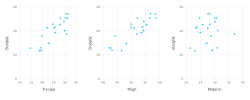

In [3]:
# Parameter1= width; Parameter2 = height.
set_default_plot_size(25cm, 10cm)
plot1 = Gadfly.plot(data, x = :Triceps, y = :Bodyfat)
plot2 = Gadfly.plot(data, x = :Thigh, y = :Bodyfat)
plot3 = Gadfly.plot(data, x = :Midarm, y = :Bodyfat)
hstack(plot1, plot2, plot3)
# gridstack([plot1 plot2 plot3])

### Réponse
Les nuages de points générés par les deux premières relations (Bodyfat vs Tricep) et (Bodyfat vs Thigh) ont une tendance globale linéaire. Parmi ces deux, le nuage de point généré par la première relation (Bodyfat vs Thigh) semble (visuellement) suivre une tendance plus linéaire que la première (Bodyfat vs Tricep), car les points semblent répartis de façon plus homogène selon un axe imaginaire. La troisième relation (Bodyfat vs Midarm) a des point plus dispersés (la relation linéaire ne semble pas appropriée pour cette relation).

## b) Estimation des paramètres de la régression linéaire simple avec $x₁$


In [4]:
# Function to compute beta0_cap and beta1_cap
function compute_beta_vals(x::Vector{Float64}, y::Vector{Float64})
    # Compute beta1_cap and beta0_cap.
    beta1_cap = cov(x, y) / var(x)
    beta0_cap = mean(y) - (beta1_cap * mean(x)) 

    # Return beta0_cap and beta1_cap as a tuple
    return beta0_cap, beta1_cap
end

# Extract the data columns from the dataframe.
x1 = data.Triceps
y = data.Bodyfat

# Compute beta1_cap and beta0_cap.
beta0_cap, beta1_cap = compute_beta_vals(x1, y)

# Display the results.
display(beta0_cap)
display(beta1_cap)

-1.4961046410368937

0.8571865102168305

In [5]:
# Vous devriez obtenir β̂₀ = -1.50 et β̂₁ = 0.857.

## c) Affichage de la droite de régression obtenue

Superposez au nuage de points précédent la droite de régression estimée. Vous pouvez utiliser la géométrie `Geom.abline()` de *Gadfly*. 

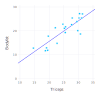

In [6]:
# Parameter1= width; Parameter2 = height.
set_default_plot_size(10cm, 10cm)
plot4 = Gadfly.plot(
    data, 
    x = :Triceps, 
    y = :Bodyfat,
    Geom.point,
    Geom.abline(color="blue"),
    slope=[beta1_cap],
    intercept=[beta0_cap]
    )

## d) Calcul du coefficient de détermination

Calculez le coefficient de détermination de la régression.

In [7]:
# Function to compute the determination coefficient.
function compute_determination_coeff(x::Vector{Float64}, y::Vector{Float64})
    # Compute the total variabitity of y
    SST = sum((y .- mean(y)).^2)

    # Compute beta1_cap and beta0_cap.
    beta0_cap, beta1_cap = compute_beta_vals(x, y)

    # Compute the variability of y associated to regression
    y_cap = (beta1_cap .* x) .+ beta0_cap
    SSR = sum((y_cap .- mean(y)).^2)

    # Compute and return the determination coefficient of the regression (R_sq = SSR / SST)
    return SSR / SST
end


R1_sq = compute_determination_coeff(x1, y)

0.711096615555969

In [8]:
# Vous devriez obtenir R² = 0.7110966155559691

## e) Interprétation du modèle de régression

Donnez une interprétation de 
- de l'estimation de l'ordonnée à l'origine $β̂₀$ ;
- de l'estimation de la pente $β̂₁$ ;
- du coefficient de détermination $R²$ .

### Réponse ( 1e )

- L'interprétation de l'ordonnée à l'origine (β̂₀ = -1.50) est que s'il y avait des personnes ayant des épaisseurs des plis de la peau des triceps nulles, alors la moyenne prévue pour le pourcentage de matière grasse serait de -1.50 unité. Cette interprétation n'est pas applicable puisqu'il n'existe pas des personnes ayant des épaisseurs de plis de triceps nulles.

- L'interprétation de la pente (β̂₁ = 0.857) est que le pourcentage de matière grasse augmente de 0.857 unité pour chaque millimètre d'augmentation de l'épaisseur des plis de la peau des triceps.

- L'interprétation du coéfficient de détermination (R² = 0.711) est que l'épaisseur des plis des triceps expliquent 71% de la variation observée du pourcentage de matière grasse.

## f)  Identification du meilleur modèle unidimensionnel

Identifiez lequel parmi les trois modèles de régression linéaire simple est le meilleur pour prédire le pourcentage de matière grasse d'un patient ? Justifier quantitativement votre réponse. 

Indice : calculez le coefficient de détermination de chacun des modèles et sélectionnez celui ayant le plus grand.

In [9]:
# Extract the columns Thigh and Midarm from the dataframe.
x2 = data.Thigh
x3 = data.Midarm

# Calculate the determination coefficients
R2_sq = compute_determination_coeff(x2, y)
R3_sq = compute_determination_coeff(x3, y)

# Display the values of R1_sq, R2_sq, and R3_sq (to compare)
println("R1_sq = $(R1_sq)")
println("R2_sq = $(R2_sq)")
println("R3_sq = $(R3_sq)")

R1_sq = 0.711096615555969
R2_sq = 0.7710414083275704
R3_sq = 0.02029030188132378


### Réponse ( 1f )
Le meilleurs modèle pour prédire le pourcentage de matière grasse est le second modèle, parce que son coefficient de détermination est le plus élevés (parmi les trois modèles). Les trois valeurs (coefficient de détermination) sont affichées juste au dessus de cette cellule.

# Exercice 2 - Régression linéaire multiple

Dans cet exercice, les trois variables explicatives seront utilisées pour prédire le pourcentage de matière grasse d'un patient.

## a) Estimation des paramètres de la régression linéaire multiple

En utilisant les trois variables explicatives, estimez les paramètres de la régression linéaire multiple avec la méthode des moindres carrés.

In [10]:
# Convert the predictors to a matrix. Then, add an intercept colum of 1s.
X = hcat(ones(nrow(data)), Matrix(data[:, [:Triceps, :Thigh, :Midarm]]))

# Calculate beta (vector) : β = (X'X)^(-1) X'y
X_transpose_X = X' * X
X_transpose_y = X' * y # y = data.Bodyfat (has been defined above).

# Verify if the matrix is singular before trying inversion
if rank(X_transpose_X) < size(X_transpose_X, 1)
    error("The matrix is singular.")
end

beta_cap = inv(X_transpose_X) * (X_transpose_y)
print(beta_cap)


[117.08469477778999, 4.33409200830647, -2.8568479362365906, -2.186060251656272]

In [11]:
# Vous devriez obtenir β̂ = [117.0846947802495, 4.334092008375274, -2.856847936298782, -2.186060251693594]

## b) Calcul du coefficient de détermination 


Calculez le coefficient de détermination et comparez-le à ceux de la question 1 (f). Pouvez-vous conclure que ce modèle est meilleur ?

In [12]:
# Compute the predicted values.
y_cap_multiple_reg = X * beta_cap

# Compute the total sum of squares
SST = sum((y .- mean(y)).^2)

# Compute the variability of y associated to regression
SSR = sum((y_cap_multiple_reg .- mean(y)).^2)

# Compute the determination coefficient of the multiple regression (R_sq = SSR / SST)
R_sq_mul_reg = SSR / SST

# Display the R_sq values for the multiple regression model and for the three linear regression models :
println("R_sq_mul_reg = $(R_sq_mul_reg)")
println("R1_sq = $(R1_sq)")
println("R2_sq = $(R2_sq)")
println("R3_sq = $(R3_sq)")


R_sq_mul_reg = 0.8013585508691569
R1_sq = 0.711096615555969
R2_sq = 0.7710414083275704
R3_sq = 0.02029030188132378


In [13]:
# Vous devriez obtenir R² = 0.8013585508623703

### Réponse ( 2b )
Le meilleurs modèle pour prédire le pourcentage de matière grasse est le modèle de regression multiple, car le coefficient de détermination de ce modèle est plus élevé que le coefficient de détermination obtenu pour chaque modèle de regression linéaire simple.

## c) Calcul d'une prédiction

Si une patiente possède les caractérisques suivantes :

 - $x_1$ = 25.0
 - $x_2$ = 51.0
 - $x_3$ = 27.5
 
 Quelle est la meilleure prédiction pour son pourcentagede pourcentage de graisse ?

In [14]:
# Calcul de la prédiction selon la formule y_pred = bata_0 + (sum(beta_i * x_i))
y_pred = beta_cap[1] + (beta_cap[2] * 25.0) + (beta_cap[3] * 51.0) + (beta_cap[4] * 27.5)

19.62109331683814

In [15]:
# Vous devriez obtenir 19.6

## d) Calcul des coefficients de régression à l'aide de la décomposition QR

Pour rendre les calculs numériques stables et efficaces, les coefficients de régressions sont généralement calculés à l'aide de la décomposition QR de la matrice de structure X, *i.e.*
$$ X = QR.$$

On peut montrer (Exercice 1 de la fin du chapitre 2 des notes de cours) que 

$$ β̂ = R^{-1} Q^\top y.$$

L'opération de la décomposition QR et de la résolution du système linéaire s'effectue en une commande à l'aide de l'opérateur `\`.

Estimez les coefficients de régression avec la commande `β̂ = X \ y`. Obtenez-vous les mêmes résultats ?


In [16]:
# Estimate beta from the formula beta_cap_QR = R_inverse * Q_trasp * y
beta_cap_QR = X \ y
print(beta_cap_QR)

[117.08469477513403, 4.33409200822082, -2.856847936166421, -2.186060251612095]

### Réponse ( 2d ) - Observation
Le même vecteur est obtenu par la nouvelle formule (en comparaison au vecteur obtenu à la question "2a")

Pour de grands jeux de données, cette solution est beaucoup plus performante et précise. Pour de petits jeux de données tel que celui-ci, ce n'est pas plus rapide de passer par la décomposition QR mais ça demeure plus précis numériquement.